## Laboratorio #3
# Redes Neuronales Recurrentes y LSTM

Clasificación de sentimiento (positivo/negativo) sobre el dataset IMDB Reviews, comparando un MLP (baseline), una RNN simple y una LSTM.

In [1]:
import re
import time
import collections

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Usando device: {device}")

Usando device: mps


## 1. Dataset

Trabajaremos con el dataset público **IMDB Reviews**, un problema de clasificación binaria de sentimiento (positivo / negativo) sobre reseñas de películas en texto. A diferencia de los laboratorios anteriores, aquí cada observación es una secuencia de longitud variable.

In [2]:
# El identificador clásico "imdb" usa un script de carga que la librería datasets>=4.0 ya no soporta;
# se usa el mirror en formato parquet "stanfordnlp/imdb", que contiene exactamente los mismos datos.
try:
    imdb = load_dataset("imdb")
except Exception:
    imdb = load_dataset("stanfordnlp/imdb")

imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

## 2. Exploración y preparación de los datos

**¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?**

In [3]:
train_texts_full = imdb["train"]["text"]
train_labels_full = imdb["train"]["label"]
test_texts = imdb["test"]["text"]
test_labels = imdb["test"]["label"]

print(f"Observaciones en train: {len(train_texts_full)}")
print(f"Observaciones en test:  {len(test_texts)}")
print(f"Clases: {sorted(set(train_labels_full))} (0 = negativo, 1 = positivo)")

print("\nDistribución de clases en train:")
print(pd.Series(train_labels_full).value_counts().sort_index())
print("\nDistribución de clases en test:")
print(pd.Series(test_labels).value_counts().sort_index())

Observaciones en train: 25000
Observaciones en test:  25000
Clases: [0, 1] (0 = negativo, 1 = positivo)

Distribución de clases en train:
0    12500
1    12500
Name: count, dtype: int64

Distribución de clases en test:
0    12500
1    12500
Name: count, dtype: int64


El dataset tiene 25,000 reseñas de entrenamiento y 25,000 de prueba, con 2 clases (0 = negativo, 1 = positivo). Ambos splits están perfectamente balanceados (12,500 / 12,500 en cada clase), por lo que no se requieren técnicas de balanceo ni pesos de clase en la función de pérdida.

**¿Cuál es la longitud de las reseñas? Reporte mínimo, máximo, promedio y grafique la distribución.**

Tokenización de 25000 reseñas en 0.5s

Longitud mínima:   10
Longitud máxima:   2482
Longitud promedio: 236.5
Longitud mediana:  176.0
Percentil 50: 176 tokens
Percentil 75: 288 tokens
Percentil 90: 463 tokens
Percentil 95: 606 tokens
Percentil 99: 920 tokens


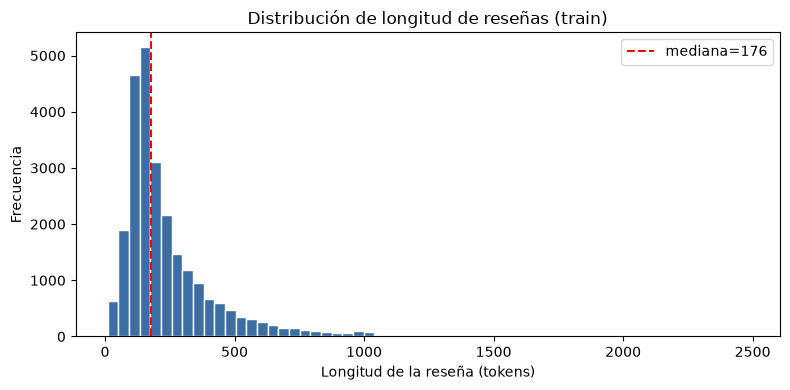

In [4]:
token_re = re.compile(r"[A-Za-z']+")

def tokenize(text):
    """Tokenización simple: minúsculas + secuencias de letras (se descartan números y puntuación)."""
    return token_re.findall(text.lower())

t0 = time.time()
train_tokens_full = [tokenize(t) for t in train_texts_full]
lengths_full = np.array([len(toks) for toks in train_tokens_full])
print(f"Tokenización de {len(train_tokens_full)} reseñas en {time.time() - t0:.1f}s")

print(f"\nLongitud mínima:   {lengths_full.min()}")
print(f"Longitud máxima:   {lengths_full.max()}")
print(f"Longitud promedio: {lengths_full.mean():.1f}")
print(f"Longitud mediana:  {np.median(lengths_full):.1f}")
for p in [50, 75, 90, 95, 99]:
    print(f"Percentil {p}: {np.percentile(lengths_full, p):.0f} tokens")

plt.figure(figsize=(8, 4))
plt.hist(lengths_full, bins=60, color="#3b6ea5", edgecolor="white")
plt.axvline(np.median(lengths_full), color="red", linestyle="--", label=f"mediana={np.median(lengths_full):.0f}")
plt.xlabel("Longitud de la reseña (tokens)")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitud de reseñas (train)")
plt.legend()
plt.tight_layout()
plt.show()

Las reseñas varían mucho en longitud (desde unas pocas palabras hasta más de 2,000 tokens), con una distribución sesgada a la derecha: la mediana (~175 tokens) es bastante menor que el máximo. La mayoría de las reseñas se concentra por debajo de los 300-400 tokens, por lo que truncar en ese rango descarta poca información relevante para la mayoría de los ejemplos.

**¿Qué estrategia de tokenización usarán? ¿Qué tamaño de vocabulario obtienen y cómo manejarán las palabras fuera de vocabulario?**

In [5]:
def build_vocab(token_lists, max_vocab_size=20000, min_freq=2):
    """Construye un vocabulario a partir de las frecuencias de palabras del set de entrenamiento."""
    counter = collections.Counter()
    for toks in token_lists:
        counter.update(toks)

    stoi = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.most_common():
        if freq < min_freq or len(stoi) >= max_vocab_size:
            break
        stoi[word] = len(stoi)
    return stoi, counter

VOCAB_SIZE = 20000
vocab, word_counter = build_vocab(train_tokens_full, max_vocab_size=VOCAB_SIZE, min_freq=2)
PAD_IDX, UNK_IDX = vocab["<pad>"], vocab["<unk>"]

print(f"Palabras únicas totales en train: {len(word_counter)}")
print(f"Tamaño del vocabulario usado: {len(vocab)} (incluye <pad> y <unk>)")

# Tasa de palabras fuera de vocabulario (OOV) en test, para ver el impacto de <unk>
test_tokens_sample = [tokenize(t) for t in test_texts[:3000]]
total_tokens = sum(len(t) for t in test_tokens_sample)
oov_tokens = sum(1 for toks in test_tokens_sample for tok in toks if tok not in vocab)
print(f"Tasa de OOV estimada en test: {oov_tokens / total_tokens:.2%}")

Palabras únicas totales en train: 85680
Tamaño del vocabulario usado: 20000 (incluye <pad> y <unk>)
Tasa de OOV estimada en test: 3.05%


Se usa una tokenización simple basada en expresiones regulares (minúsculas, secuencias de letras), que evita depender de librerías externas de NLP y es suficiente para un problema de sentimiento en inglés. El vocabulario se limita a las 20,000 palabras más frecuentes con al menos 2 apariciones en train; cualquier palabra fuera de ese conjunto (incluyendo las de test/validación no vistas) se mapea al token especial `<unk>`. La tasa de OOV resultante es baja (~3%), ya que las palabras más frecuentes cubren la gran mayoría de las apariciones en el corpus.

**¿Por qué es necesario aplicar padding y/o truncamiento a las secuencias antes de agruparlas en batches? ¿Qué longitud máxima de secuencia eligieron y por qué?**

In [6]:
MAX_LEN = 150

pct_covered = (lengths_full <= MAX_LEN).mean()
print(f"MAX_LEN elegido: {MAX_LEN} tokens")
print(f"Porcentaje de reseñas de train que caben completas en {MAX_LEN} tokens: {pct_covered:.1%}")

MAX_LEN elegido: 150 tokens
Porcentaje de reseñas de train que caben completas en 150 tokens: 38.6%


PyTorch agrupa los tensores de un batch en un único tensor rectangular, por lo que todas las secuencias de un batch deben tener la misma longitud: el **padding** rellena las secuencias cortas con un token especial (`<pad>`) y el **truncamiento** recorta las secuencias muy largas para acotar el costo computacional y de memoria. Se eligió `MAX_LEN = 150` tokens como tope de truncamiento: la mediana de longitud es de 176 tokens, por lo que solo el 38.6% de las reseñas caben completas en 150 tokens, pero truncar ahí mantiene el entrenamiento eficiente sin descartar la mayor parte de la información (la mayoría del contenido más informativo de una reseña suele concentrarse al inicio) — este trade-off entre cobertura y costo computacional se explora explícitamente en la sección 4.1 con longitudes de 50 y 400 tokens; el padding real de cada batch se hace de forma dinámica (hasta la secuencia más larga del batch, no siempre hasta 150) usando `pad_sequence`, y `pack_padded_sequence`/`pad_packed_sequence` se usan dentro de la RNN/LSTM para que las posiciones de padding no afecten el cómputo del estado oculto. En la sección 4.1 se compara además el efecto de usar `MAX_LEN` mucho más pequeño (50) y mucho más grande (400).

**Visualice al menos 5 ejemplos del dataset (texto y etiqueta) junto con su longitud en tokens.**

In [7]:
label_names = {0: "negativo", 1: "positivo"}
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(train_texts_full), size=5, replace=False)

for i in sample_idx:
    text = train_texts_full[i]
    toks = train_tokens_full[i]
    print(f"Índice: {i} | Etiqueta: {label_names[train_labels_full[i]]} | Longitud: {len(toks)} tokens")
    print(text[:300].replace("\n", " ") + ("..." if len(text) > 300 else ""))
    print("-" * 100)

Índice: 6868 | Etiqueta: negativo | Longitud: 114 tokens
Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version of "The Three Amigos", only without any laughs. In order for black comedy to work, it must be outra...
----------------------------------------------------------------------------------------------------
Índice: 24016 | Etiqueta: positivo | Longitud: 141 tokens
I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards for Best Picture of 1951 and Best Screenplay. The story of an American painter in Paris who tries to make it big. Nina Foch...
----------------------------------------------------------------------------------------------------
Índice: 9668 | Etiqueta: negativo | Longitud: 228 tokens
After watching thi

**División en entrenamiento, validación y test**

Se conserva el split oficial de test (25,000 reseñas) para la evaluación final única, y se divide el split de train oficial (25,000 reseñas) en entrenamiento (90%) y validación (10%).

In [8]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.10, random_state=SEED, stratify=train_labels_full
)

print(f"Train: {len(train_texts)} reseñas")
print(f"Val:   {len(val_texts)} reseñas")
print(f"Test:  {len(test_texts)} reseñas")

Train: 22500 reseñas
Val:   2500 reseñas
Test:  25000 reseñas


## 3. Investigación: capas de PyTorch para RNN y LSTM

**`nn.Embedding`**: capa de lookup que mapea índices enteros de tokens a vectores densos entrenables. Parámetros relevantes: `num_embeddings` (tamaño del vocabulario), `embedding_dim` (dimensión del vector), y `padding_idx` (índice que se fija en cero y no recibe gradiente, usado para el token `<pad>`).

**`nn.RNN`**: red recurrente simple que procesa una secuencia paso a paso, manteniendo un estado oculto `h_t = tanh(W_ih x_t + W_hh h_{t-1} + b)`. Parámetros relevantes: `input_size`, `hidden_size`, `num_layers` (apilar varias capas recurrentes), `batch_first` (para que el tensor de entrada tenga forma `(batch, seq, feature)`), `nonlinearity` (`tanh` o `relu`) y `dropout` (entre capas si `num_layers > 1`). Devuelve la secuencia de salidas y el último estado oculto `h_n`.

**`nn.LSTM`**: variante recurrente con memoria de largo plazo (celda `c_t`) y tres compuertas (forget, input, output) que regulan qué información se olvida, se agrega y se expone como salida. Comparte parámetros con `nn.RNN` (`input_size`, `hidden_size`, `num_layers`, `batch_first`, `dropout`) pero internamente usa ~4 veces más parámetros por capa al tener 4 conjuntos de pesos (uno por compuerta y uno para la celda candidata). Devuelve la secuencia de salidas y una tupla `(h_n, c_n)`.

**`nn.utils.rnn.pad_sequence` / `pack_padded_sequence` / `pad_packed_sequence`**: utilidades para manejar secuencias de longitud variable en batch. `pad_sequence` recibe una lista de tensores de distinta longitud y los junta en un único tensor rellenando con un valor de padding (usado típicamente dentro de un `collate_fn`). `pack_padded_sequence` empaqueta ese tensor ya paddeado junto con las longitudes reales de cada secuencia en una estructura `PackedSequence`, que le indica a la RNN/LSTM exactamente cuántos pasos reales procesar por ejemplo (evitando que el padding contamine el estado oculto). `pad_packed_sequence` hace el proceso inverso: convierte una `PackedSequence` (por ejemplo, la salida de la RNN) de vuelta a un tensor denso con padding, útil cuando se necesita la salida en cada paso de tiempo (arquitecturas many-to-many).

**`torch.nn.utils.clip_grad_norm_`**: recorta (clip) la norma global de los gradientes de todos los parámetros a un valor máximo (`max_norm`) antes de `optimizer.step()`. Es la técnica estándar para controlar el *exploding gradient* en RNN/LSTM, ya que evita que un gradiente anormalmente grande en un paso de tiempo destruya los pesos aprendidos.

**`nn.Dropout` en capas recurrentes**: aplicado sobre la salida de la capa recurrente (o entre capas apiladas vía el parámetro `dropout` de `nn.RNN`/`nn.LSTM`) para regularizar el modelo, apagando aleatoriamente activaciones durante el entrenamiento y reduciendo el sobreajuste, de forma análoga a su uso en un MLP.

In [9]:
# Demostración concreta de pad_sequence -> pack_padded_sequence -> pad_packed_sequence
toy_seqs = [torch.tensor([5, 8, 2, 9]), torch.tensor([3, 1]), torch.tensor([7, 4, 6])]
toy_lengths = torch.tensor([len(s) for s in toy_seqs])

padded = nn.utils.rnn.pad_sequence(toy_seqs, batch_first=True, padding_value=0)
print("Secuencias originales (longitudes distintas):", [s.tolist() for s in toy_seqs])
print("\npad_sequence -> tensor denso con padding:\n", padded)

packed = nn.utils.rnn.pack_padded_sequence(padded, toy_lengths, batch_first=True, enforce_sorted=False)
print("\npack_padded_sequence -> PackedSequence (solo contiene posiciones reales, sin padding):")
print(packed)

unpacked, unpacked_lengths = nn.utils.rnn.pad_packed_sequence(packed, batch_first=True)
print("\npad_packed_sequence -> tensor denso reconstruido:\n", unpacked)
print("Longitudes recuperadas:", unpacked_lengths.tolist())

Secuencias originales (longitudes distintas): [[5, 8, 2, 9], [3, 1], [7, 4, 6]]

pad_sequence -> tensor denso con padding:
 tensor([[5, 8, 2, 9],
        [3, 1, 0, 0],
        [7, 4, 6, 0]])

pack_padded_sequence -> PackedSequence (solo contiene posiciones reales, sin padding):
PackedSequence(data=tensor([5, 7, 3, 8, 4, 1, 2, 6, 9]), batch_sizes=tensor([3, 3, 2, 1]), sorted_indices=tensor([0, 2, 1]), unsorted_indices=tensor([0, 2, 1]))

pad_packed_sequence -> tensor denso reconstruido:
 tensor([[5, 8, 2, 9],
        [3, 1, 0, 0],
        [7, 4, 6, 0]])
Longitudes recuperadas: [4, 2, 3]


## 4. Construcción y entrenamiento de las arquitecturas

Se construyen tres arquitecturas: un MLP (baseline, con pooling promedio de embeddings), una RNN simple many-to-one y una LSTM many-to-one, todas compartiendo la misma capa de embedding inicial y el mismo pipeline de datos.

In [10]:
class IMDBDataset(Dataset):
    """Cada ítem retorna (ids de tokens, longitud real, etiqueta); el padding se hace por batch en collate_fn."""
    def __init__(self, texts, labels, vocab, max_len):
        self.texts, self.labels, self.vocab, self.max_len = texts, labels, vocab, max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        toks = tokenize(self.texts[idx])[:self.max_len]
        ids = [self.vocab.get(t, UNK_IDX) for t in toks]
        if not ids:
            ids = [UNK_IDX]
        return torch.tensor(ids, dtype=torch.long), len(ids), self.labels[idx]


def collate_fn(batch):
    """Usa pad_sequence para rellenar dinámicamente cada batch hasta su secuencia más larga."""
    seqs, lengths, labels = zip(*batch)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    return padded, torch.tensor(lengths, dtype=torch.long), torch.tensor(labels, dtype=torch.long)


def make_loaders(max_len, batch_size=128):
    train_ds = IMDBDataset(train_texts, train_labels, vocab, max_len)
    val_ds = IMDBDataset(val_texts, val_labels, vocab, max_len)
    test_ds = IMDBDataset(test_texts, test_labels, vocab, max_len)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    return train_loader, val_loader, test_loader


BATCH_SIZE = 128
train_loader, val_loader, test_loader = make_loaders(MAX_LEN, BATCH_SIZE)
print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches -> train: 176, val: 20, test: 196


In [11]:
class MLPClassifier(nn.Module):
    """Baseline: promedio de los embeddings de la reseña (ignorando padding) + MLP clasificador."""
    def __init__(self, vocab_size, emb_dim, hidden_layers, dropout=0.0, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        layers = []
        in_features = emb_dim
        for h in hidden_layers:
            layers += [nn.Linear(in_features, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = h
        layers.append(nn.Linear(in_features, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        mask = (x != PAD_IDX).unsqueeze(-1).float()
        pooled = (emb * mask).sum(dim=1) / lengths.unsqueeze(-1).float().clamp(min=1).to(emb.device)
        return self.classifier(pooled)


class RNNClassifier(nn.Module):
    """RNN simple many-to-one: usa el último hidden state (h_n de la última capa) para clasificar."""
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=1, dropout=0.0, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(emb_dim, hidden_size, num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.rnn(packed)
        last_hidden = h_n[-1]
        return self.fc(self.dropout(last_hidden))


class LSTMClassifier(nn.Module):
    """LSTM many-to-one, misma configuración que la RNN pero con memoria de celda y compuertas."""
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=1, dropout=0.0, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hidden_size, num_layers=num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, c_n) = self.lstm(packed)
        last_hidden = h_n[-1]
        return self.fc(self.dropout(last_hidden))

In [12]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def run_epoch(model, loader, criterion, optimizer=None, clip_norm=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    y_true, y_pred = [], []
    for xb, lb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train_mode:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train_mode):
            logits = model(xb, lb)
            loss = criterion(logits, yb)
            if train_mode:
                loss.backward()
                if clip_norm is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(yb.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(y_true, y_pred)
    return avg_loss, metrics, np.array(y_true), np.array(y_pred)


def fit_model(model, train_loader, val_loader, epochs, lr, weight_decay=0.0, clip_norm=None):
    """Entrena `model`, registra loss/metrics por epoch y conserva el mejor estado según F1 de validación."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state, best_val_f1, best_val_metrics = None, -1.0, None
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer, clip_norm)
        val_loss, val_metrics, _, _ = run_epoch(model, val_loader, criterion, None)
        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        })
        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_val_metrics = val_metrics
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    train_time = time.time() - t0
    return history, best_state, best_val_metrics, train_time


def evaluate_model(model, loader):
    criterion = nn.CrossEntropyLoss()
    loss, metrics, y_true, y_pred = run_epoch(model, loader, criterion, None)
    return loss, metrics, y_true, y_pred


def run_search(arch_name, configs, build_fn, train_loader, val_loader):
    """Entrena cada configuración de `configs` y devuelve una tabla resumen + historiales + mejores pesos."""
    results, histories, states = [], [], []
    for cfg in configs:
        torch.manual_seed(SEED)
        model = build_fn(cfg)
        history, best_state, best_val_metrics, train_time = fit_model(
            model, train_loader, val_loader,
            epochs=cfg["epochs"], lr=cfg["lr"],
            weight_decay=cfg.get("weight_decay", 0.0), clip_norm=cfg.get("clip_norm"),
        )
        n_params = count_trainable_params(model)
        results.append({
            "arquitectura": arch_name, "config": cfg["name"], "params": n_params,
            "train_time_s": train_time,
            **{f"val_{k}": v for k, v in best_val_metrics.items()},
        })
        histories.append(history)
        states.append(best_state)
        print(f"[{arch_name}] {cfg['name']:20s} params={n_params:>9,}  "
              f"val_f1={best_val_metrics['f1']:.4f}  val_acc={best_val_metrics['accuracy']:.4f}  "
              f"time={train_time:.1f}s")
    return pd.DataFrame(results), histories, states

### 4.1 MLP (baseline)

Iteraciones sobre arquitectura (número/tamaño de capas), dropout y learning rate.

In [13]:
EPOCHS_MAIN = 5

mlp_configs = [
    {"name": "baseline",     "emb_dim": 100, "hidden_layers": [128, 64], "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "deeper",       "emb_dim": 100, "hidden_layers": [256, 128, 64], "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "dropout_0.3",  "emb_dim": 100, "hidden_layers": [128, 64], "dropout": 0.3, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "lr_low",       "emb_dim": 100, "hidden_layers": [128, 64], "dropout": 0.0, "lr": 1e-4, "epochs": EPOCHS_MAIN},
    {"name": "dropout_wd",   "emb_dim": 100, "hidden_layers": [128, 64], "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4, "epochs": EPOCHS_MAIN},
]

def build_mlp(cfg):
    return MLPClassifier(len(vocab), cfg["emb_dim"], cfg["hidden_layers"], dropout=cfg["dropout"])

mlp_results_df, mlp_histories, mlp_states = run_search("MLP", mlp_configs, build_mlp, train_loader, val_loader)
mlp_results_df.sort_values("val_f1", ascending=False).reset_index(drop=True)

[MLP] baseline             params=2,021,314  val_f1=0.8464  val_acc=0.8464  time=10.8s


[MLP] deeper               params=2,067,138  val_f1=0.8444  val_acc=0.8444  time=9.8s


[MLP] dropout_0.3          params=2,021,314  val_f1=0.8496  val_acc=0.8496  time=10.6s


[MLP] lr_low               params=2,021,314  val_f1=0.7424  val_acc=0.7424  time=9.2s


[MLP] dropout_wd           params=2,021,314  val_f1=0.8224  val_acc=0.8224  time=9.8s


,arquitectura,config,params,train_time_s,val_accuracy,val_precision,val_recall,val_f1
0,MLP,dropout_0.3,2021314,10.597204,0.8496,0.849608,0.8496,0.849599
1,MLP,baseline,2021314,10.831889,0.8464,0.846656,0.8464,0.846372
2,MLP,deeper,2067138,9.787951,0.8444,0.844640,0.8444,0.844373
3,MLP,dropout_wd,2021314,9.837817,0.8224,0.822453,0.8224,0.822393
4,MLP,lr_low,2021314,9.209423,0.7424,0.742462,0.7424,0.742384


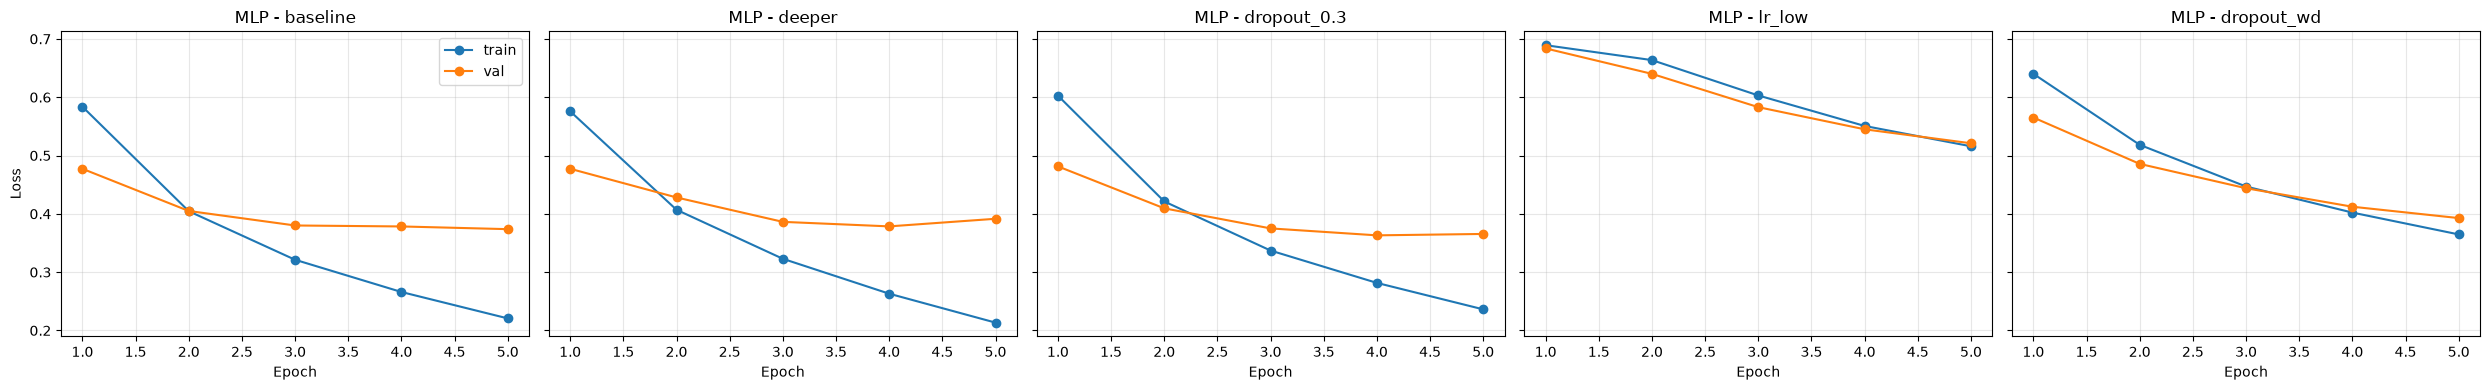

In [14]:
fig, axes = plt.subplots(1, len(mlp_histories), figsize=(5 * len(mlp_histories), 4), sharey=True)
for ax, hist, cfg in zip(axes, mlp_histories, mlp_configs):
    epochs = [h["epoch"] for h in hist]
    ax.plot(epochs, [h["train_loss"] for h in hist], marker="o", label="train")
    ax.plot(epochs, [h["val_loss"] for h in hist], marker="o", label="val")
    ax.set_title(f"MLP - {cfg['name']}")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
axes[0].legend()
plt.tight_layout()
plt.show()

### 4.2 RNN simple (`nn.RNN`)

Iteraciones sobre tamaño del hidden state, número de capas (con dropout entre capas), gradient clipping y learning rate.

In [15]:
rnn_configs = [
    {"name": "baseline",       "emb_dim": 100, "hidden_size": 128, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "hidden_256",     "emb_dim": 100, "hidden_size": 256, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "2_layers",       "emb_dim": 100, "hidden_size": 128, "num_layers": 2, "dropout": 0.3, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "grad_clip",      "emb_dim": 100, "hidden_size": 128, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN, "clip_norm": 5.0},
    {"name": "lr_low",         "emb_dim": 100, "hidden_size": 128, "num_layers": 1, "dropout": 0.0, "lr": 1e-4, "epochs": EPOCHS_MAIN},
]

def build_rnn(cfg):
    return RNNClassifier(len(vocab), cfg["emb_dim"], cfg["hidden_size"], num_layers=cfg["num_layers"], dropout=cfg["dropout"])

rnn_results_df, rnn_histories, rnn_states = run_search("RNN", rnn_configs, build_rnn, train_loader, val_loader)
rnn_results_df.sort_values("val_f1", ascending=False).reset_index(drop=True)

[RNN] baseline             params=2,029,698  val_f1=0.6929  val_acc=0.6972  time=85.3s


[RNN] hidden_256           params=2,092,162  val_f1=0.5290  val_acc=0.5388  time=85.0s


[RNN] 2_layers             params=2,062,722  val_f1=0.6258  val_acc=0.6260  time=161.4s


[RNN] grad_clip            params=2,029,698  val_f1=0.6204  val_acc=0.6304  time=96.7s


[RNN] lr_low               params=2,029,698  val_f1=0.6728  val_acc=0.6728  time=121.8s


,arquitectura,config,params,train_time_s,val_accuracy,val_precision,val_recall,val_f1
0,RNN,baseline,2029698,85.295726,0.6972,0.708831,0.6972,0.692924
1,RNN,lr_low,2029698,121.753814,0.6728,0.672875,0.6728,0.672765
2,RNN,2_layers,2062722,161.424646,0.6260,0.626210,0.6260,0.625844
3,RNN,grad_clip,2029698,96.715899,0.6304,0.645779,0.6304,0.620388
4,RNN,hidden_256,2092162,84.956217,0.5388,0.542331,0.5388,0.528979


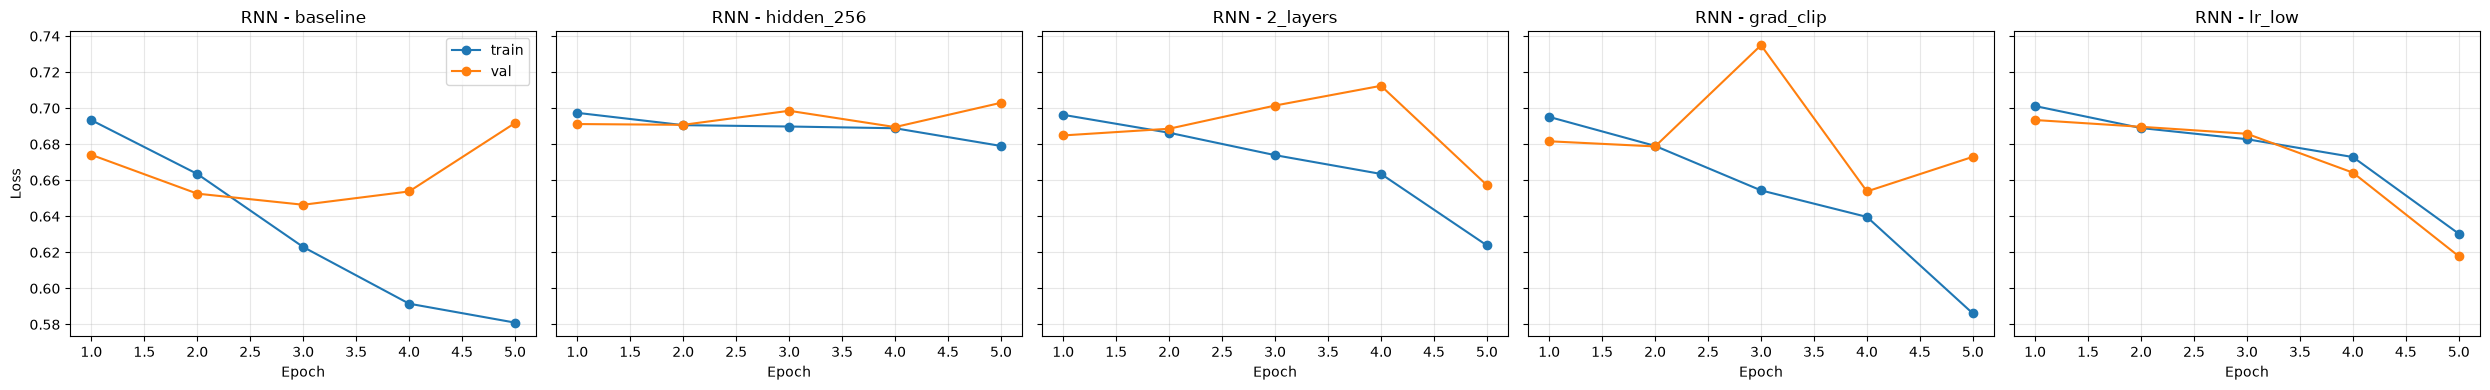

In [16]:
fig, axes = plt.subplots(1, len(rnn_histories), figsize=(5 * len(rnn_histories), 4), sharey=True)
for ax, hist, cfg in zip(axes, rnn_histories, rnn_configs):
    epochs = [h["epoch"] for h in hist]
    ax.plot(epochs, [h["train_loss"] for h in hist], marker="o", label="train")
    ax.plot(epochs, [h["val_loss"] for h in hist], marker="o", label="val")
    ax.set_title(f"RNN - {cfg['name']}")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
axes[0].legend()
plt.tight_layout()
plt.show()

### 4.3 LSTM (`nn.LSTM`)

Misma malla de hiperparámetros que la RNN, para poder comparar directamente el efecto de las compuertas de memoria.

In [17]:
lstm_configs = [
    {"name": "baseline",       "emb_dim": 100, "hidden_size": 128, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "hidden_256",     "emb_dim": 100, "hidden_size": 256, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "2_layers",       "emb_dim": 100, "hidden_size": 128, "num_layers": 2, "dropout": 0.3, "lr": 1e-3, "epochs": EPOCHS_MAIN},
    {"name": "grad_clip",      "emb_dim": 100, "hidden_size": 128, "num_layers": 1, "dropout": 0.0, "lr": 1e-3, "epochs": EPOCHS_MAIN, "clip_norm": 5.0},
    {"name": "lr_low",         "emb_dim": 100, "hidden_size": 128, "num_layers": 1, "dropout": 0.0, "lr": 1e-4, "epochs": EPOCHS_MAIN},
]

def build_lstm(cfg):
    return LSTMClassifier(len(vocab), cfg["emb_dim"], cfg["hidden_size"], num_layers=cfg["num_layers"], dropout=cfg["dropout"])

lstm_results_df, lstm_histories, lstm_states = run_search("LSTM", lstm_configs, build_lstm, train_loader, val_loader)
lstm_results_df.sort_values("val_f1", ascending=False).reset_index(drop=True)

[LSTM] baseline             params=2,118,018  val_f1=0.7418  val_acc=0.7420  time=227.7s


[LSTM] hidden_256           params=2,367,106  val_f1=0.7762  val_acc=0.7768  time=293.1s


[LSTM] 2_layers             params=2,250,114  val_f1=0.8013  val_acc=0.8016  time=472.7s


[LSTM] grad_clip            params=2,118,018  val_f1=0.7783  val_acc=0.7788  time=276.0s


[LSTM] lr_low               params=2,118,018  val_f1=0.7380  val_acc=0.7380  time=264.1s


,arquitectura,config,params,train_time_s,val_accuracy,val_precision,val_recall,val_f1
0,LSTM,2_layers,2250114,472.718073,0.8016,0.803172,0.8016,0.801343
1,LSTM,grad_clip,2118018,276.002253,0.7788,0.781264,0.7788,0.778314
2,LSTM,hidden_256,2367106,293.066586,0.7768,0.780018,0.7768,0.776157
3,LSTM,baseline,2118018,227.682019,0.7420,0.742783,0.7420,0.741792
4,LSTM,lr_low,2118018,264.052976,0.7380,0.738166,0.7380,0.737954


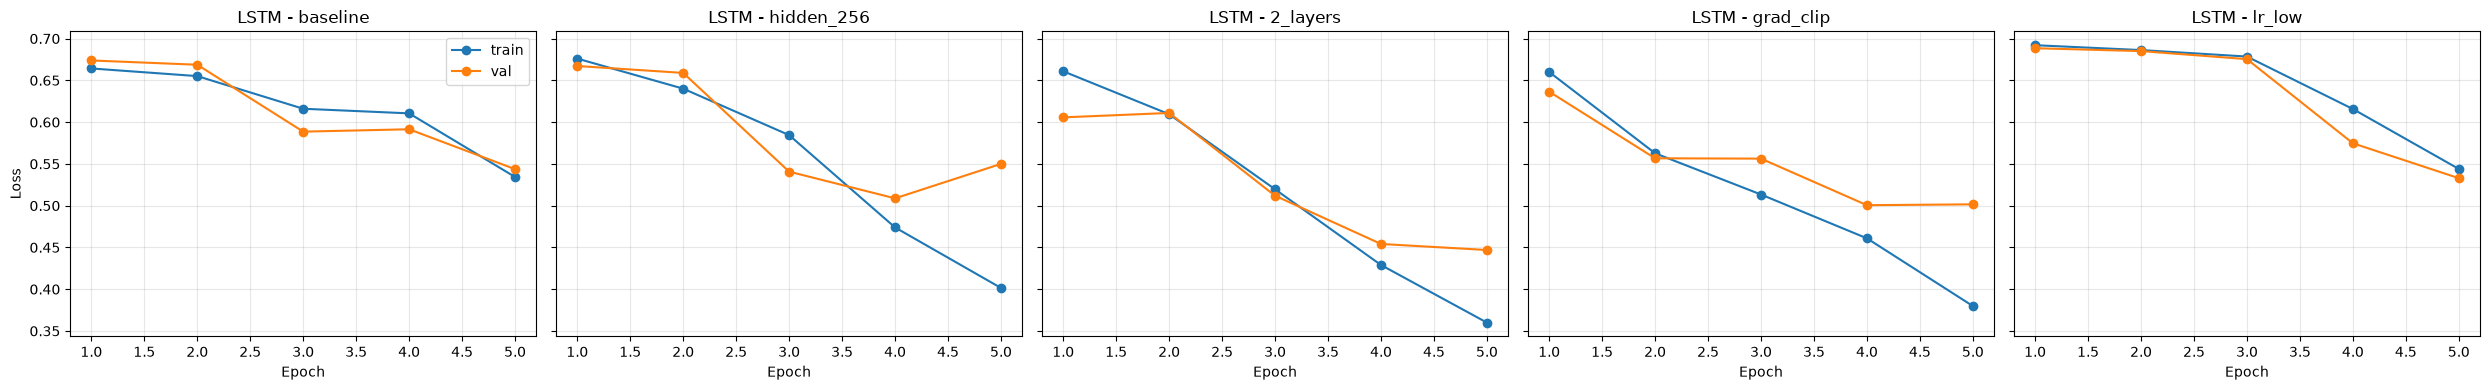

In [18]:
fig, axes = plt.subplots(1, len(lstm_histories), figsize=(5 * len(lstm_histories), 4), sharey=True)
for ax, hist, cfg in zip(axes, lstm_histories, lstm_configs):
    epochs = [h["epoch"] for h in hist]
    ax.plot(epochs, [h["train_loss"] for h in hist], marker="o", label="train")
    ax.plot(epochs, [h["val_loss"] for h in hist], marker="o", label="val")
    ax.set_title(f"LSTM - {cfg['name']}")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Loss")
axes[0].legend()
plt.tight_layout()
plt.show()

### Evaluación final única sobre el conjunto de test

Se selecciona la mejor configuración de cada arquitectura según F1 macro de validación, y se evalúa cada una una única vez sobre el conjunto de test.

In [19]:
all_results_df = pd.concat([mlp_results_df, rnn_results_df, lstm_results_df], ignore_index=True)

arch_registry = {
    "MLP":  {"configs": mlp_configs,  "results": mlp_results_df,  "states": mlp_states,  "build_fn": build_mlp},
    "RNN":  {"configs": rnn_configs,  "results": rnn_results_df,  "states": rnn_states,  "build_fn": build_rnn},
    "LSTM": {"configs": lstm_configs, "results": lstm_results_df, "states": lstm_states, "build_fn": build_lstm},
}

best_models, best_cfgs, final_reports = {}, {}, []

for arch, reg in arch_registry.items():
    best_idx = reg["results"]["val_f1"].idxmax()
    best_cfg = reg["configs"][best_idx]
    best_state = reg["states"][best_idx]

    model = reg["build_fn"](best_cfg).to(device)
    model.load_state_dict(best_state)

    test_loss, test_metrics, y_true, y_pred = evaluate_model(model, test_loader)

    best_models[arch] = model
    best_cfgs[arch] = best_cfg
    final_reports.append({
        "arquitectura": arch,
        "mejor_config": best_cfg["name"],
        "params": count_trainable_params(model),
        "train_time_s": reg["results"].loc[best_idx, "train_time_s"],
        "test_loss": test_loss,
        **test_metrics,
    })
    print(f"{arch:5s} mejor config: {best_cfg['name']:15s} -> test_acc={test_metrics['accuracy']:.4f}  "
          f"test_f1={test_metrics['f1']:.4f}")

final_reports_df = pd.DataFrame(final_reports)
final_reports_df

MLP   mejor config: dropout_0.3     -> test_acc=0.8279  test_f1=0.8278


RNN   mejor config: baseline        -> test_acc=0.6847  test_f1=0.6802


LSTM  mejor config: 2_layers        -> test_acc=0.8015  test_f1=0.8014


,arquitectura,mejor_config,params,train_time_s,test_loss,accuracy,precision,recall,f1
0,MLP,dropout_0.3,2021314,10.597204,0.404087,0.82792,0.828798,0.82792,0.827805
1,RNN,baseline,2029698,85.295726,0.657287,0.68468,0.695659,0.68468,0.680194
2,LSTM,2_layers,2250114,472.718073,0.454565,0.80148,0.802033,0.80148,0.801389


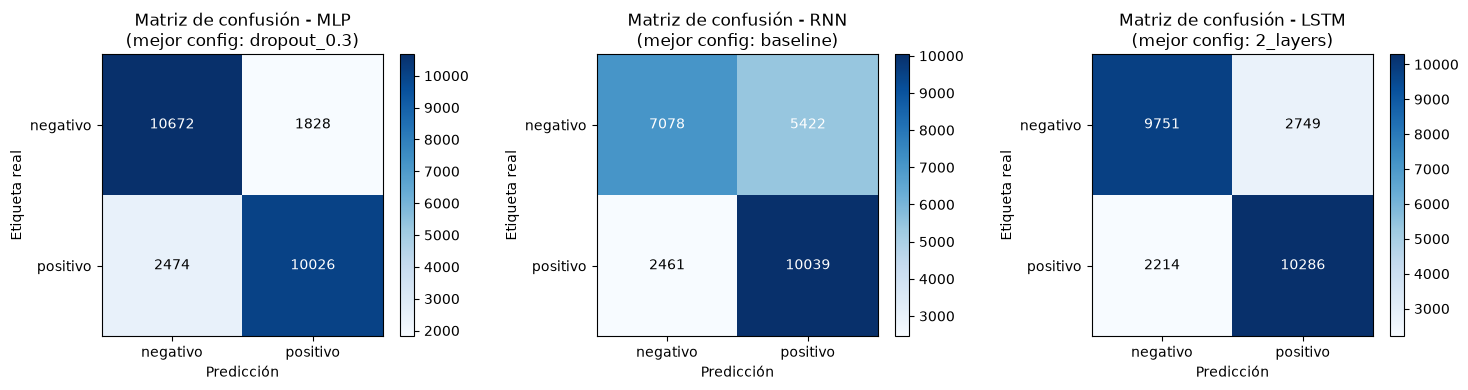

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, arch in zip(axes, ["MLP", "RNN", "LSTM"]):
    model = best_models[arch]
    _, _, y_true, y_pred = evaluate_model(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Matriz de confusión - {arch}\n(mejor config: {best_cfgs[arch]['name']})")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["negativo", "positivo"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["negativo", "positivo"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 4.1 Experimento adicional: efecto de la longitud de secuencia

Se toman las mejores configuraciones de la RNN y la LSTM (según F1 de validación con `MAX_LEN=150`) y se reentrenan/evalúan desde cero sobre dos versiones del dataset con longitudes máximas muy distintas: reseñas truncadas a **50 tokens** vs. reseñas truncadas a **400 tokens**.

In [21]:
SEQ_LEN_VARIANTS = [50, 400]
seq_len_results = []
seq_len_histories = {}

for max_len in SEQ_LEN_VARIANTS:
    tr_loader, va_loader, te_loader = make_loaders(max_len, BATCH_SIZE)
    for arch, build_fn, cfg in [("RNN", build_rnn, best_cfgs["RNN"]), ("LSTM", build_lstm, best_cfgs["LSTM"])]:
        torch.manual_seed(SEED)
        model = build_fn(cfg)
        history, best_state, best_val_metrics, train_time = fit_model(
            model, tr_loader, va_loader,
            epochs=cfg["epochs"], lr=cfg["lr"],
            weight_decay=cfg.get("weight_decay", 0.0), clip_norm=cfg.get("clip_norm"),
        )
        model.load_state_dict(best_state)
        test_loss, test_metrics, y_true, y_pred = evaluate_model(model, te_loader)

        seq_len_histories[(arch, max_len)] = history
        seq_len_results.append({
            "arquitectura": arch, "max_len": max_len, "config": cfg["name"],
            "train_time_s": train_time,
            "val_f1": best_val_metrics["f1"], "val_accuracy": best_val_metrics["accuracy"],
            "test_accuracy": test_metrics["accuracy"], "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"], "test_f1": test_metrics["f1"],
        })
        print(f"max_len={max_len:4d} | {arch:5s} | val_f1={best_val_metrics['f1']:.4f} | "
              f"test_f1={test_metrics['f1']:.4f} | test_acc={test_metrics['accuracy']:.4f} | time={train_time:.1f}s")

seq_len_df = pd.DataFrame(seq_len_results)
seq_len_df

max_len=  50 | RNN   | val_f1=0.6758 | test_f1=0.6614 | test_acc=0.6623 | time=30.1s


max_len=  50 | LSTM  | val_f1=0.7724 | test_f1=0.7469 | test_acc=0.7469 | time=84.4s


max_len= 400 | RNN   | val_f1=0.6693 | test_f1=0.6819 | test_acc=0.6829 | time=412.3s


max_len= 400 | LSTM  | val_f1=0.6243 | test_f1=0.6400 | test_acc=0.6652 | time=1364.2s


,arquitectura,max_len,config,train_time_s,val_f1,val_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,RNN,50,baseline,30.086403,0.675761,0.6764,0.66232,0.664128,0.66232,0.661387
1,LSTM,50,2_layers,84.393846,0.772373,0.7724,0.74688,0.746997,0.74688,0.746850
2,RNN,400,baseline,412.308534,0.669276,0.6700,0.68288,0.685058,0.68288,0.681944
3,LSTM,400,2_layers,1364.237586,0.624291,0.6540,0.66516,0.729244,0.66516,0.640001


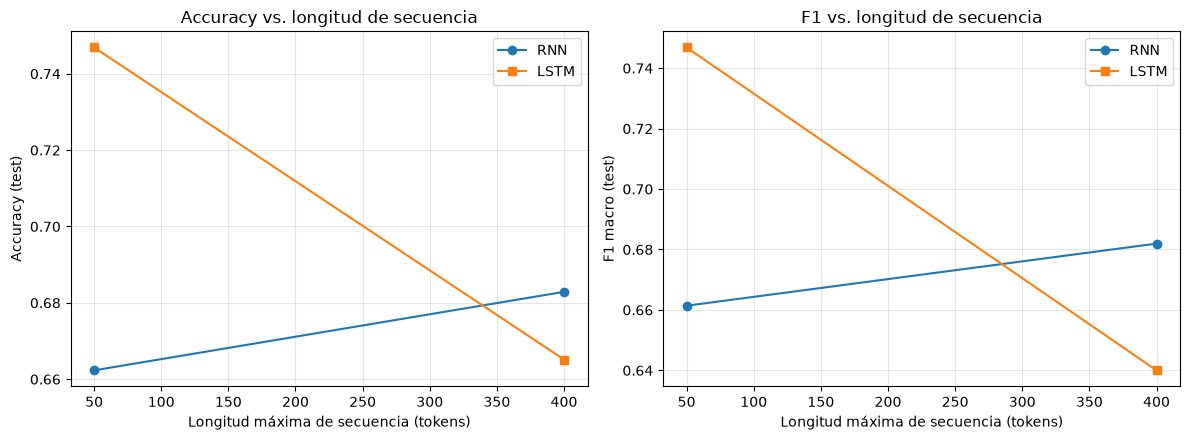

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for arch, marker in [("RNN", "o"), ("LSTM", "s")]:
    sub = seq_len_df[seq_len_df["arquitectura"] == arch].sort_values("max_len")
    axes[0].plot(sub["max_len"], sub["test_accuracy"], marker=marker, label=arch)
    axes[1].plot(sub["max_len"], sub["test_f1"], marker=marker, label=arch)

axes[0].set_xlabel("Longitud máxima de secuencia (tokens)")
axes[0].set_ylabel("Accuracy (test)")
axes[0].set_title("Accuracy vs. longitud de secuencia")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Longitud máxima de secuencia (tokens)")
axes[1].set_ylabel("F1 macro (test)")
axes[1].set_title("F1 vs. longitud de secuencia")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

*(El análisis de este experimento, junto con su relación con el problema de vanishing gradient, se retoma en la sección de Discusión.)*

## 5. Comparación de arquitecturas

Comparación directa entre el MLP, la RNN y la LSTM usando la mejor configuración de cada una (entrenadas y evaluadas con `MAX_LEN=150`).

In [23]:
comparison_df = final_reports_df[[
    "arquitectura", "mejor_config", "params", "train_time_s",
    "accuracy", "precision", "recall", "f1",
]].rename(columns={
    "mejor_config": "Mejor config", "params": "Parámetros", "train_time_s": "Tiempo entren. (s)",
    "accuracy": "Accuracy", "precision": "Precision", "recall": "Recall", "f1": "F1",
})
comparison_df

,arquitectura,Mejor config,Parámetros,Tiempo entren. (s),Accuracy,Precision,Recall,F1
0,MLP,dropout_0.3,2021314,10.597204,0.82792,0.828798,0.82792,0.827805
1,RNN,baseline,2029698,85.295726,0.68468,0.695659,0.68468,0.680194
2,LSTM,2_layers,2250114,472.718073,0.80148,0.802033,0.80148,0.801389


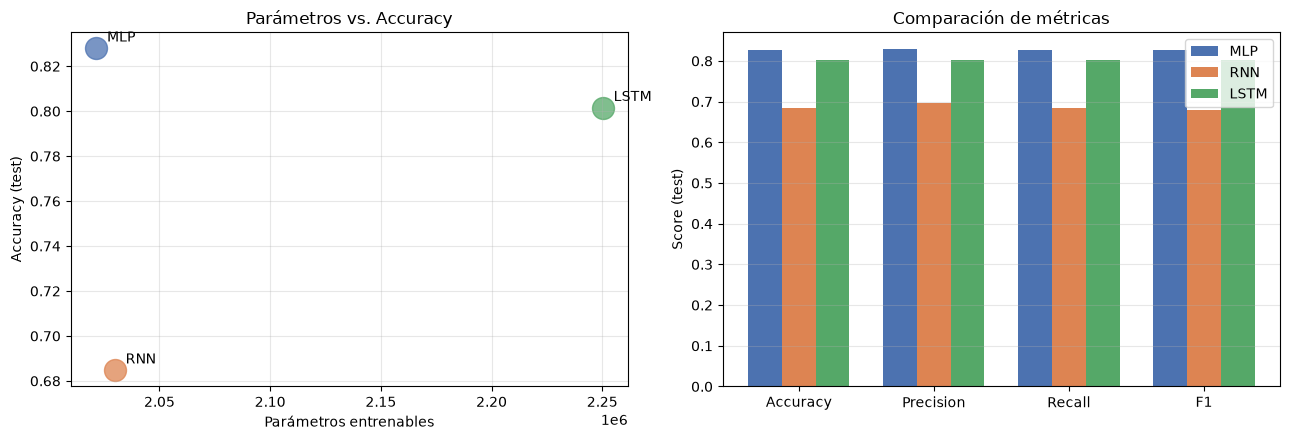

=== Resultados del experimento de longitud de secuencia (sección 4.1) ===


,arquitectura,max_len,test_accuracy,test_f1,train_time_s
0,RNN,50,0.66232,0.661387,30.086403
1,LSTM,50,0.74688,0.746850,84.393846
2,RNN,400,0.68288,0.681944,412.308534
3,LSTM,400,0.66516,0.640001,1364.237586


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {"MLP": "#4c72b0", "RNN": "#dd8452", "LSTM": "#55a868"}
for _, row in comparison_df.iterrows():
    axes[0].scatter(row["Parámetros"], row["Accuracy"], s=250, alpha=0.75,
                     color=colors[row["arquitectura"]], label=row["arquitectura"])
    axes[0].annotate(row["arquitectura"], (row["Parámetros"], row["Accuracy"]),
                      xytext=(8, 5), textcoords="offset points")
axes[0].set_xlabel("Parámetros entrenables")
axes[0].set_ylabel("Accuracy (test)")
axes[0].set_title("Parámetros vs. Accuracy")
axes[0].grid(True, alpha=0.3)

metrics_plot = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_plot))
width = 0.25
for i, arch in enumerate(["MLP", "RNN", "LSTM"]):
    row = comparison_df[comparison_df["arquitectura"] == arch].iloc[0]
    axes[1].bar(x + (i - 1) * width, [row[m] for m in metrics_plot], width, label=arch, color=colors[arch])
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics_plot)
axes[1].set_ylabel("Score (test)")
axes[1].set_title("Comparación de métricas")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("=== Resultados del experimento de longitud de secuencia (sección 4.1) ===")
seq_len_df[["arquitectura", "max_len", "test_accuracy", "test_f1", "train_time_s"]]

### Análisis de errores: ejemplos mal clasificados por cada modelo

Se inspeccionan reseñas del conjunto de test que cada modelo clasifica incorrectamente, junto con su longitud en tokens, para identificar patrones (reseñas muy largas, sarcasmo, sentimiento mixto, etc.).

In [25]:
misclassified_summary = []

for arch in ["MLP", "RNN", "LSTM"]:
    model = best_models[arch]
    _, _, y_true, y_pred = evaluate_model(model, test_loader)
    wrong_idx = np.where(y_true != y_pred)[0]

    test_lengths = np.array([len(tokenize(t)) for t in test_texts])
    wrong_lengths = test_lengths[wrong_idx]

    misclassified_summary.append({
        "arquitectura": arch,
        "n_errores": len(wrong_idx),
        "tasa_error": len(wrong_idx) / len(y_true),
        "longitud_promedio_errores": wrong_lengths.mean(),
        "longitud_promedio_test": test_lengths.mean(),
    })

    print(f"\n=== {arch}: {len(wrong_idx)} errores de {len(y_true)} ({len(wrong_idx)/len(y_true):.1%}) ===")
    print(f"Longitud promedio de reseñas mal clasificadas: {wrong_lengths.mean():.0f} tokens "
          f"(promedio general en test: {test_lengths.mean():.0f})")

    rng_err = np.random.RandomState(SEED)
    sample_wrong = rng_err.choice(wrong_idx, size=min(3, len(wrong_idx)), replace=False)
    for idx in sample_wrong:
        print(f"\n  [real={label_names[y_true[idx]]} | predicho={label_names[y_pred[idx]]} | "
              f"longitud={test_lengths[idx]} tokens]")
        print("  " + test_texts[idx][:220].replace("\n", " ") + "...")

misclassified_df = pd.DataFrame(misclassified_summary)
misclassified_df


=== MLP: 4302 errores de 25000 (17.2%) ===
Longitud promedio de reseñas mal clasificadas: 272 tokens (promedio general en test: 231)

  [real=negativo | predicho=positivo | longitud=131 tokens]
  I bought this DVD as part of a set of 50 "historic classics." It's hardly a classic, and as the plot was updated to the time of its release, is not historic either. The actual title on the DVD is "Indecent," and addition...

  [real=positivo | predicho=negativo | longitud=124 tokens]
  Picture this. Someone makes a film about the Columbine or Virginia tech massacre only the film is directed by the guy who did home alone (i know this isn't but bare with me) and stars Sean Astin off of Goonies!! picture ...

  [real=negativo | predicho=positivo | longitud=81 tokens]
  This is a silly movie with much singing and dancing. Acting is average, but writing leaves something to be desired. There are rememberable performances by Buddy Epsen, with a short but outstanding performance by Gypsy Ro...



=== RNN: 7883 errores de 25000 (31.5%) ===
Longitud promedio de reseñas mal clasificadas: 253 tokens (promedio general en test: 231)

  [real=negativo | predicho=positivo | longitud=460 tokens]
  I want very much to believe that the above quote (specifically, the English subtitle translation), which was actually written, not spoken, in a rejection letter a publisher sends to the protagonist, was meant to be self-...

  [real=negativo | predicho=positivo | longitud=413 tokens]
  "Ordinary Decent Criminal" is sort of based on the exploits of Martin Cahill, already the subject of John Boorman's 1998 film "The General". Cahill had a rough upbringing in a slum area and graduated from petty crime to ...

  [real=positivo | predicho=negativo | longitud=509 tokens]
  A bunch of mostly obnoxious and grossly unappealing teens go to a creepy, remote, rundown old mortuary located nearby a cemetery to attend an anything-goes all-out Halloween party being hosted by freaky occult-obsessed o...



=== LSTM: 4963 errores de 25000 (19.9%) ===
Longitud promedio de reseñas mal clasificadas: 267 tokens (promedio general en test: 231)

  [real=positivo | predicho=negativo | longitud=342 tokens]
  If you need that instant buzz that only late 60s/early 70s Euro sex movies can give off, then look no further for you have just stumbled across the mother lode ! Subsequent TV director Schivazappa's exercise in psychedel...

  [real=negativo | predicho=positivo | longitud=151 tokens]
  I felt that the movie Skammen, directed by Ingmar Bergman, was very dry. It shows the things people will do to survive during a war and the shame that comes out of these actions; however I feel that it was not complete o...

  [real=negativo | predicho=positivo | longitud=30 tokens]
  If it wasn't for the terrific music, I would not hesitate to give this cinematic underachievement 2/10. But the music actually makes me like certain passages, and so I give it 5/10....


,arquitectura,n_errores,tasa_error,longitud_promedio_errores,longitud_promedio_test
0,MLP,4302,0.17208,271.913529,231.14668
1,RNN,7883,0.31532,252.836230,231.14668
2,LSTM,4963,0.19852,266.796494,231.14668
